# TT-29 — TF-IDF: phân loại ticket hỗ trợ khách hàng về đúng bộ phận
Notebook chạy lần lượt 11 bước của đề bài. Logic nằm trong `src/train.py` (cùng code với `python src/train.py`),
notebook chỉ gọi từng bước và hiển thị kết quả. Tất cả bảng/biểu đồ cũng được lưu vào `reports/`.

**TF-IDF(t,d) = TF(t,d) × log(N / df(t))** — từ nhiều Ở ĐÂY nhưng hiếm Ở KHẮP NƠI thì đáng chú ý.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import pandas as pd
from IPython.display import Image, display
pd.set_option("display.max_colwidth", 90)

import train as T
from preprocess import NGUONG_TIN_CAY

def hinh(ten): display(Image(filename=str(T.REPORTS / ten)))

## Bước 1 — Chứng minh rò rỉ do headers/footers/quotes
Chạy 2 lần: CÓ và KHÔNG `remove=('headers','footers','quotes')`. Từ bước 2 chỉ dùng bản đã remove.

,Cấu hình,Accuracy,Macro-F1
0,KHÔNG remove (rò rỉ),0.853425,0.847109
1,remove headers/footers/quotes,0.683617,0.671320


Khi KHÔNG bỏ headers, accuracy = 0.853; sau khi bỏ chỉ còn 0.684 (chênh 0.170). Phần chênh này là rò rỉ: mô hình đọc dòng 'Newsgroups: ...' trong header — chính là đáp án. Ví dụ từ trọng số cao nhất của lớp 'alt.atheism' trong bản rò rỉ: atheism, atheists, islamic, keith, rushdie, edu keith, atheist, wingate. Từ bước 2 chỉ dùng bản đã remove.


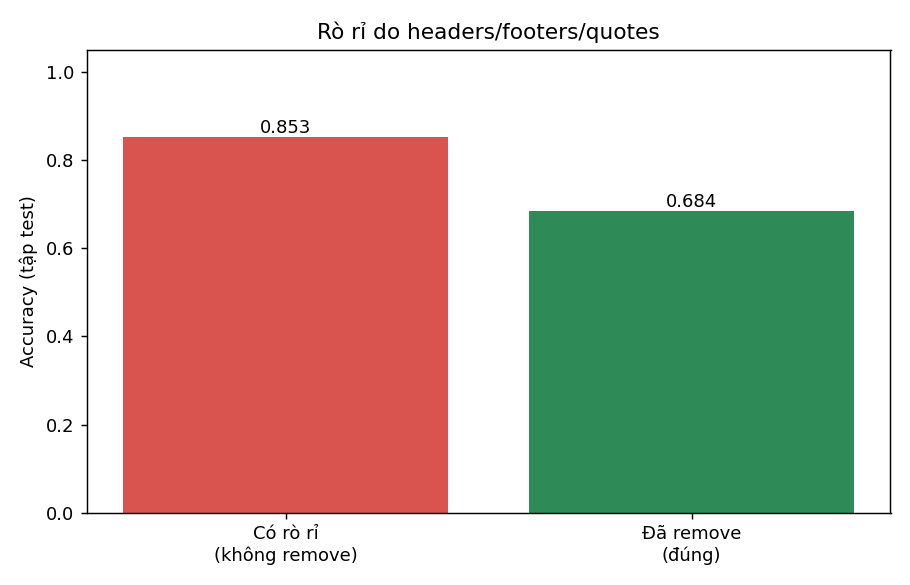

In [2]:
df1, nhan_xet = T.b1_ro_ri()
display(df1); print(nhan_xet); hinh("leakage_comparison.png")

## Bước 2 — EDA
Số văn bản mỗi lớp, độ dài văn bản, từ phổ biến nhất.

,count,mean,std,min,25%,50%,75%,max,Văn bản rỗng
Số từ / văn bản,11314.0,185.8,524.0,0.0,40.0,83.0,167.0,11765.0,300


,0,10,12,8,2,6,7,16,14,15,1,11,5,3,19,9,4,17,18,13
Từ,ax,max,people,like,don,just,know,use,think,time,does,new,good,edu,way,make,god,used,ve,say
Số lần,62387,4585,4103,3964,3885,3752,3487,3179,3011,2968,2782,2609,2507,2436,2038,2030,1980,1880,1850,1849


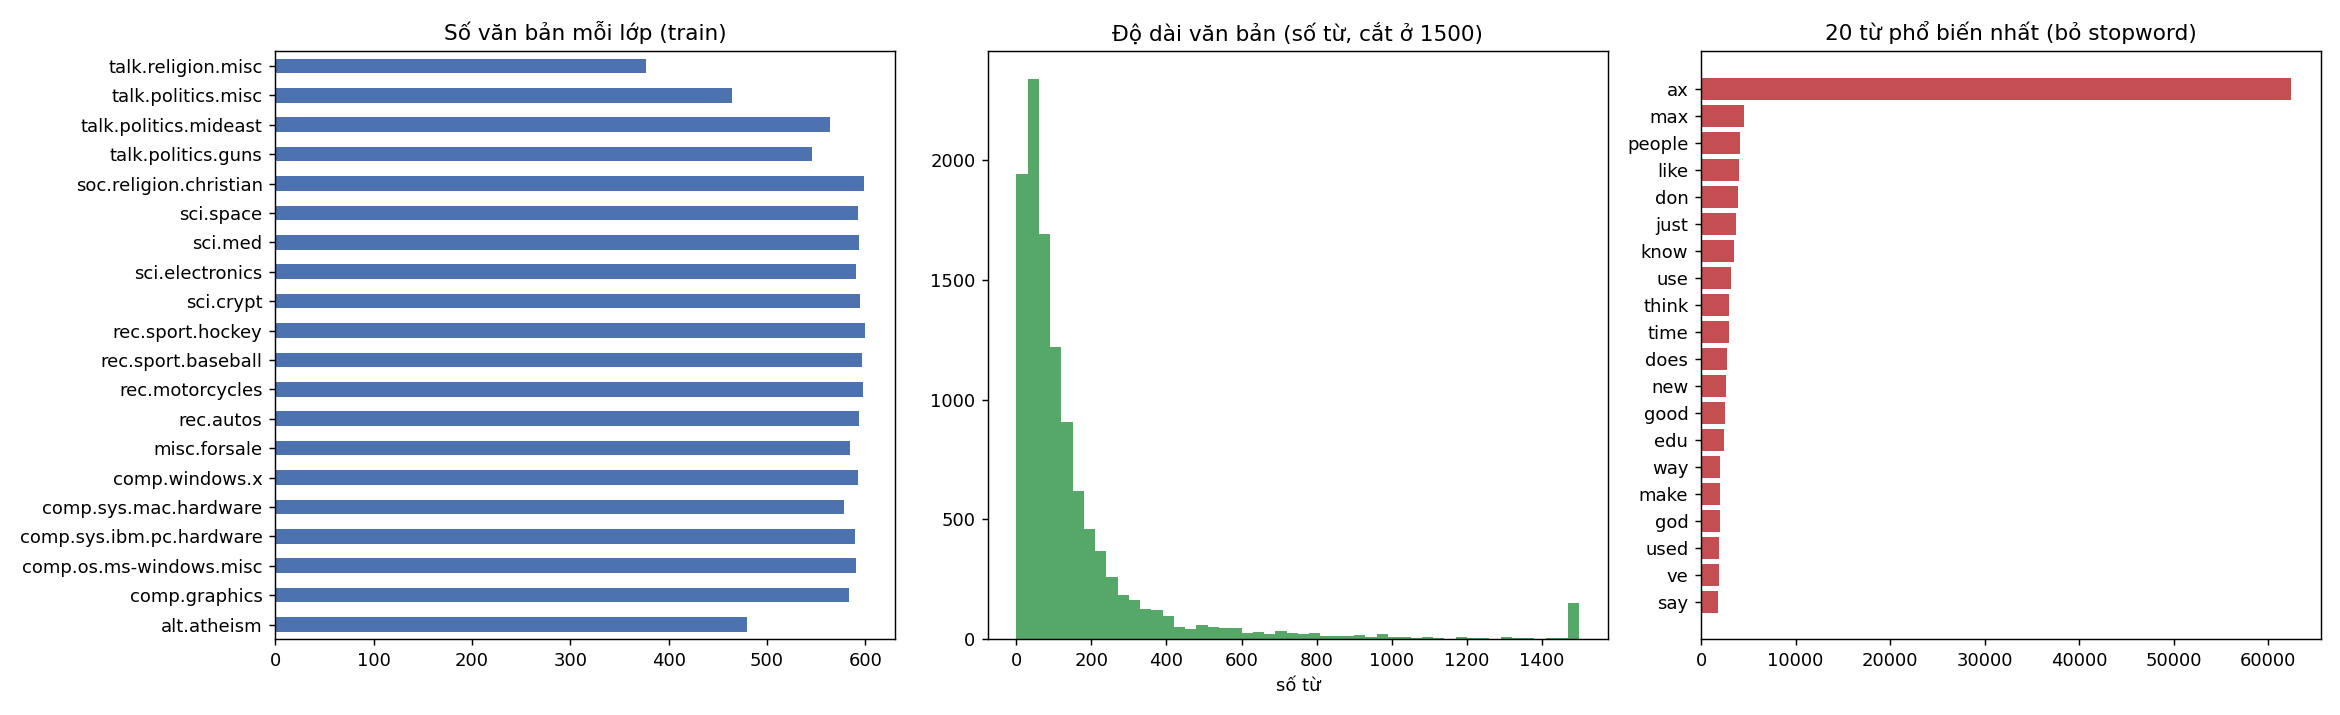

In [3]:
counts, stats, top = T.b2_eda()
display(stats); display(top.T); hinh("eda.png")

## Bước 3 — Baseline: DummyClassifier + Naive Bayes

In [4]:
T.b3_baseline()

,Baseline,Accuracy,Macro-F1
0,DummyClassifier (lớp phổ biến nhất),0.052974,0.005031
1,TF-IDF + Naive Bayes,0.669543,0.646533


## Bước 4 — TF-IDF + LinearSVC (bọc `CalibratedClassifierCV` để có xác suất)
Model được lưu vào `models/tfidf_pipeline.joblib`.

In [5]:
fin = T.b4_fit_final()
print(f"Accuracy = {fin['acc']:.4f} | Macro-F1 = {fin['f1']:.4f}")
fin["report"]

Accuracy = 0.6855 | Macro-F1 = 0.6749


,precision,recall,f1-score,support
alt.atheism,0.526,0.514,0.520,319.000
comp.graphics,0.633,0.684,0.658,389.000
comp.os.ms-windows.misc,0.645,0.594,0.618,394.000
comp.sys.ibm.pc.hardware,0.622,0.566,0.593,392.000
comp.sys.mac.hardware,0.732,0.701,0.716,385.000
comp.windows.x,0.840,0.691,0.758,395.000
misc.forsale,0.822,0.779,0.800,390.000
rec.autos,0.506,0.745,0.603,396.000
rec.motorcycles,0.721,0.761,0.741,398.000
rec.sport.baseball,0.853,0.791,0.821,397.000


## Bước 5 — Khảo sát tham số vectorizer
`ngram_range` × `min_df` × `sublinear_tf` → số đặc trưng sinh ra × accuracy (mất vài phút).

In [6]:
df5 = T.b5_khao_sat_vectorizer()
display(df5)
display(df5.pivot_table(index=["ngram_range", "min_df"], columns="sublinear_tf", values="Accuracy"))

   [b5] ngram=(1, 1) min_df=1 sublinear=True: 101,630 đặc trưng, acc=0.6995
   [b5] ngram=(1, 1) min_df=1 sublinear=False: 101,630 đặc trưng, acc=0.6922
   [b5] ngram=(1, 1) min_df=3 sublinear=True: 27,052 đặc trưng, acc=0.6903
   [b5] ngram=(1, 1) min_df=3 sublinear=False: 27,052 đặc trưng, acc=0.6840
   [b5] ngram=(1, 1) min_df=5 sublinear=True: 18,100 đặc trưng, acc=0.6818
   [b5] ngram=(1, 1) min_df=5 sublinear=False: 18,100 đặc trưng, acc=0.6743
   [b5] ngram=(1, 2) min_df=1 sublinear=True: 948,674 đặc trưng, acc=0.7066
   [b5] ngram=(1, 2) min_df=1 sublinear=False: 948,674 đặc trưng, acc=0.6976
   [b5] ngram=(1, 2) min_df=3 sublinear=True: 123,072 đặc trưng, acc=0.6918
   [b5] ngram=(1, 2) min_df=3 sublinear=False: 123,072 đặc trưng, acc=0.6868
   [b5] ngram=(1, 2) min_df=5 sublinear=True: 64,555 đặc trưng, acc=0.6856
   [b5] ngram=(1, 2) min_df=5 sublinear=False: 64,555 đặc trưng, acc=0.6784


,ngram_range,min_df,sublinear_tf,Số đặc trưng,Accuracy,Macro-F1
0,"(1, 1)",1,True,101630,0.699549,0.688468
1,"(1, 1)",1,False,101630,0.692246,0.681427
2,"(1, 1)",3,True,27052,0.690255,0.679393
3,"(1, 1)",3,False,27052,0.684015,0.673483
4,"(1, 1)",5,True,18100,0.681758,0.671260
5,"(1, 1)",5,False,18100,0.674323,0.663818
6,"(1, 2)",1,True,948674,0.706585,0.691297
7,"(1, 2)",1,False,948674,0.697557,0.683430
8,"(1, 2)",3,True,123072,0.691848,0.678699
9,"(1, 2)",3,False,123072,0.686803,0.674516


sublinear_tf           False     True 
ngram_range min_df                    
(1, 1)      1       0.692246  0.699549
            3       0.684015  0.690255
            5       0.674323  0.681758
(1, 2)      1       0.697557  0.706585
            3       0.686803  0.691848
            5       0.678439  0.685608

## Bước 6 — So sánh 3 bộ phân loại trên cùng TF-IDF

In [7]:
T.b6_so_sanh_bo_phan_loai()

,Bộ phân loại,Accuracy,Macro-F1,Thời gian train (s)
0,Naive Bayes (alpha=0.1),0.669543,0.646533,0.122617
1,Logistic Regression (C=20),0.675119,0.664516,38.491091
2,LinearSVC (C=1),0.683617,0.671320,3.481873


## Bước 7 — Top 15 từ trọng số cao nhất mỗi lớp
Kiểm tra bằng mắt: có hợp lý không? Có từ rò rỉ (header/footer) nào lọt vào không?

⚠️ Nghi rò rỉ: không có token header/footer nào trong top 15


Lớp,alt.atheism,comp.graphics,comp.os.ms-windows.misc,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,comp.windows.x,misc.forsale,rec.autos,rec.motorcycles,rec.sport.baseball,rec.sport.hockey,sci.crypt,sci.electronics,sci.med,sci.space,soc.religion.christian,talk.politics.guns,talk.politics.mideast,talk.politics.misc,talk.religion.misc
Hạng,,,,,,,,,,,,,,,,,,,,
1,atheism,graphics,windows,vlb,mac,motif,shipping,car,bike,baseball,hockey,encryption,circuit,msg,space,god,gun,israel,tax,koresh
2,atheists,3d,cica,ide,apple,server,sell,cars,dod,stadium,nhl,clipper,electronics,doctor,orbit,church,guns,israeli,clinton,kent
3,religion,image,file,controller,powerbook,widget,offer,dealer,bikes,phillies,playoff,nsa,8051,medical,launch,christ,weapons,arab,libertarians,rosicrucian
4,bobby,images,win3,bios,quadra,xterm,for sale,vw,motorcycle,alomar,team,key,voltage,disease,nasa,christianity,firearms,turkish,gay,objective
5,islamic,pov,risc,gateway,centris,x11r5,sale,ford,ride,braves,season,security,power,treatment,spacecraft,christians,firearm,jews,homosexuals,amorc
6,islam,animation,ini,bus,duo,window,forsale,gt,riding,cubs,mask,crypto,motorola,patients,moon,easter,weapon,arabs,drugs,christian
7,deletion,68070,w4wg,pc,se,sun,wanted,toyota,helmet,runs,puck,keys,dsp,diet,shuttle,scripture,nra,loser,jobs,666
8,motto,tiff,nt,486,lc,widgets,condition,oil,harley,ball,devils,tempest,scope,cancer,solar,christian,fire,armenians,deane,christians
9,atheist,viewer,win,os,adb,mit,asking,engine,bmw,era,roger,pgp,dial,health,lunar,marriage,hunting,turkey,taxes,paradise


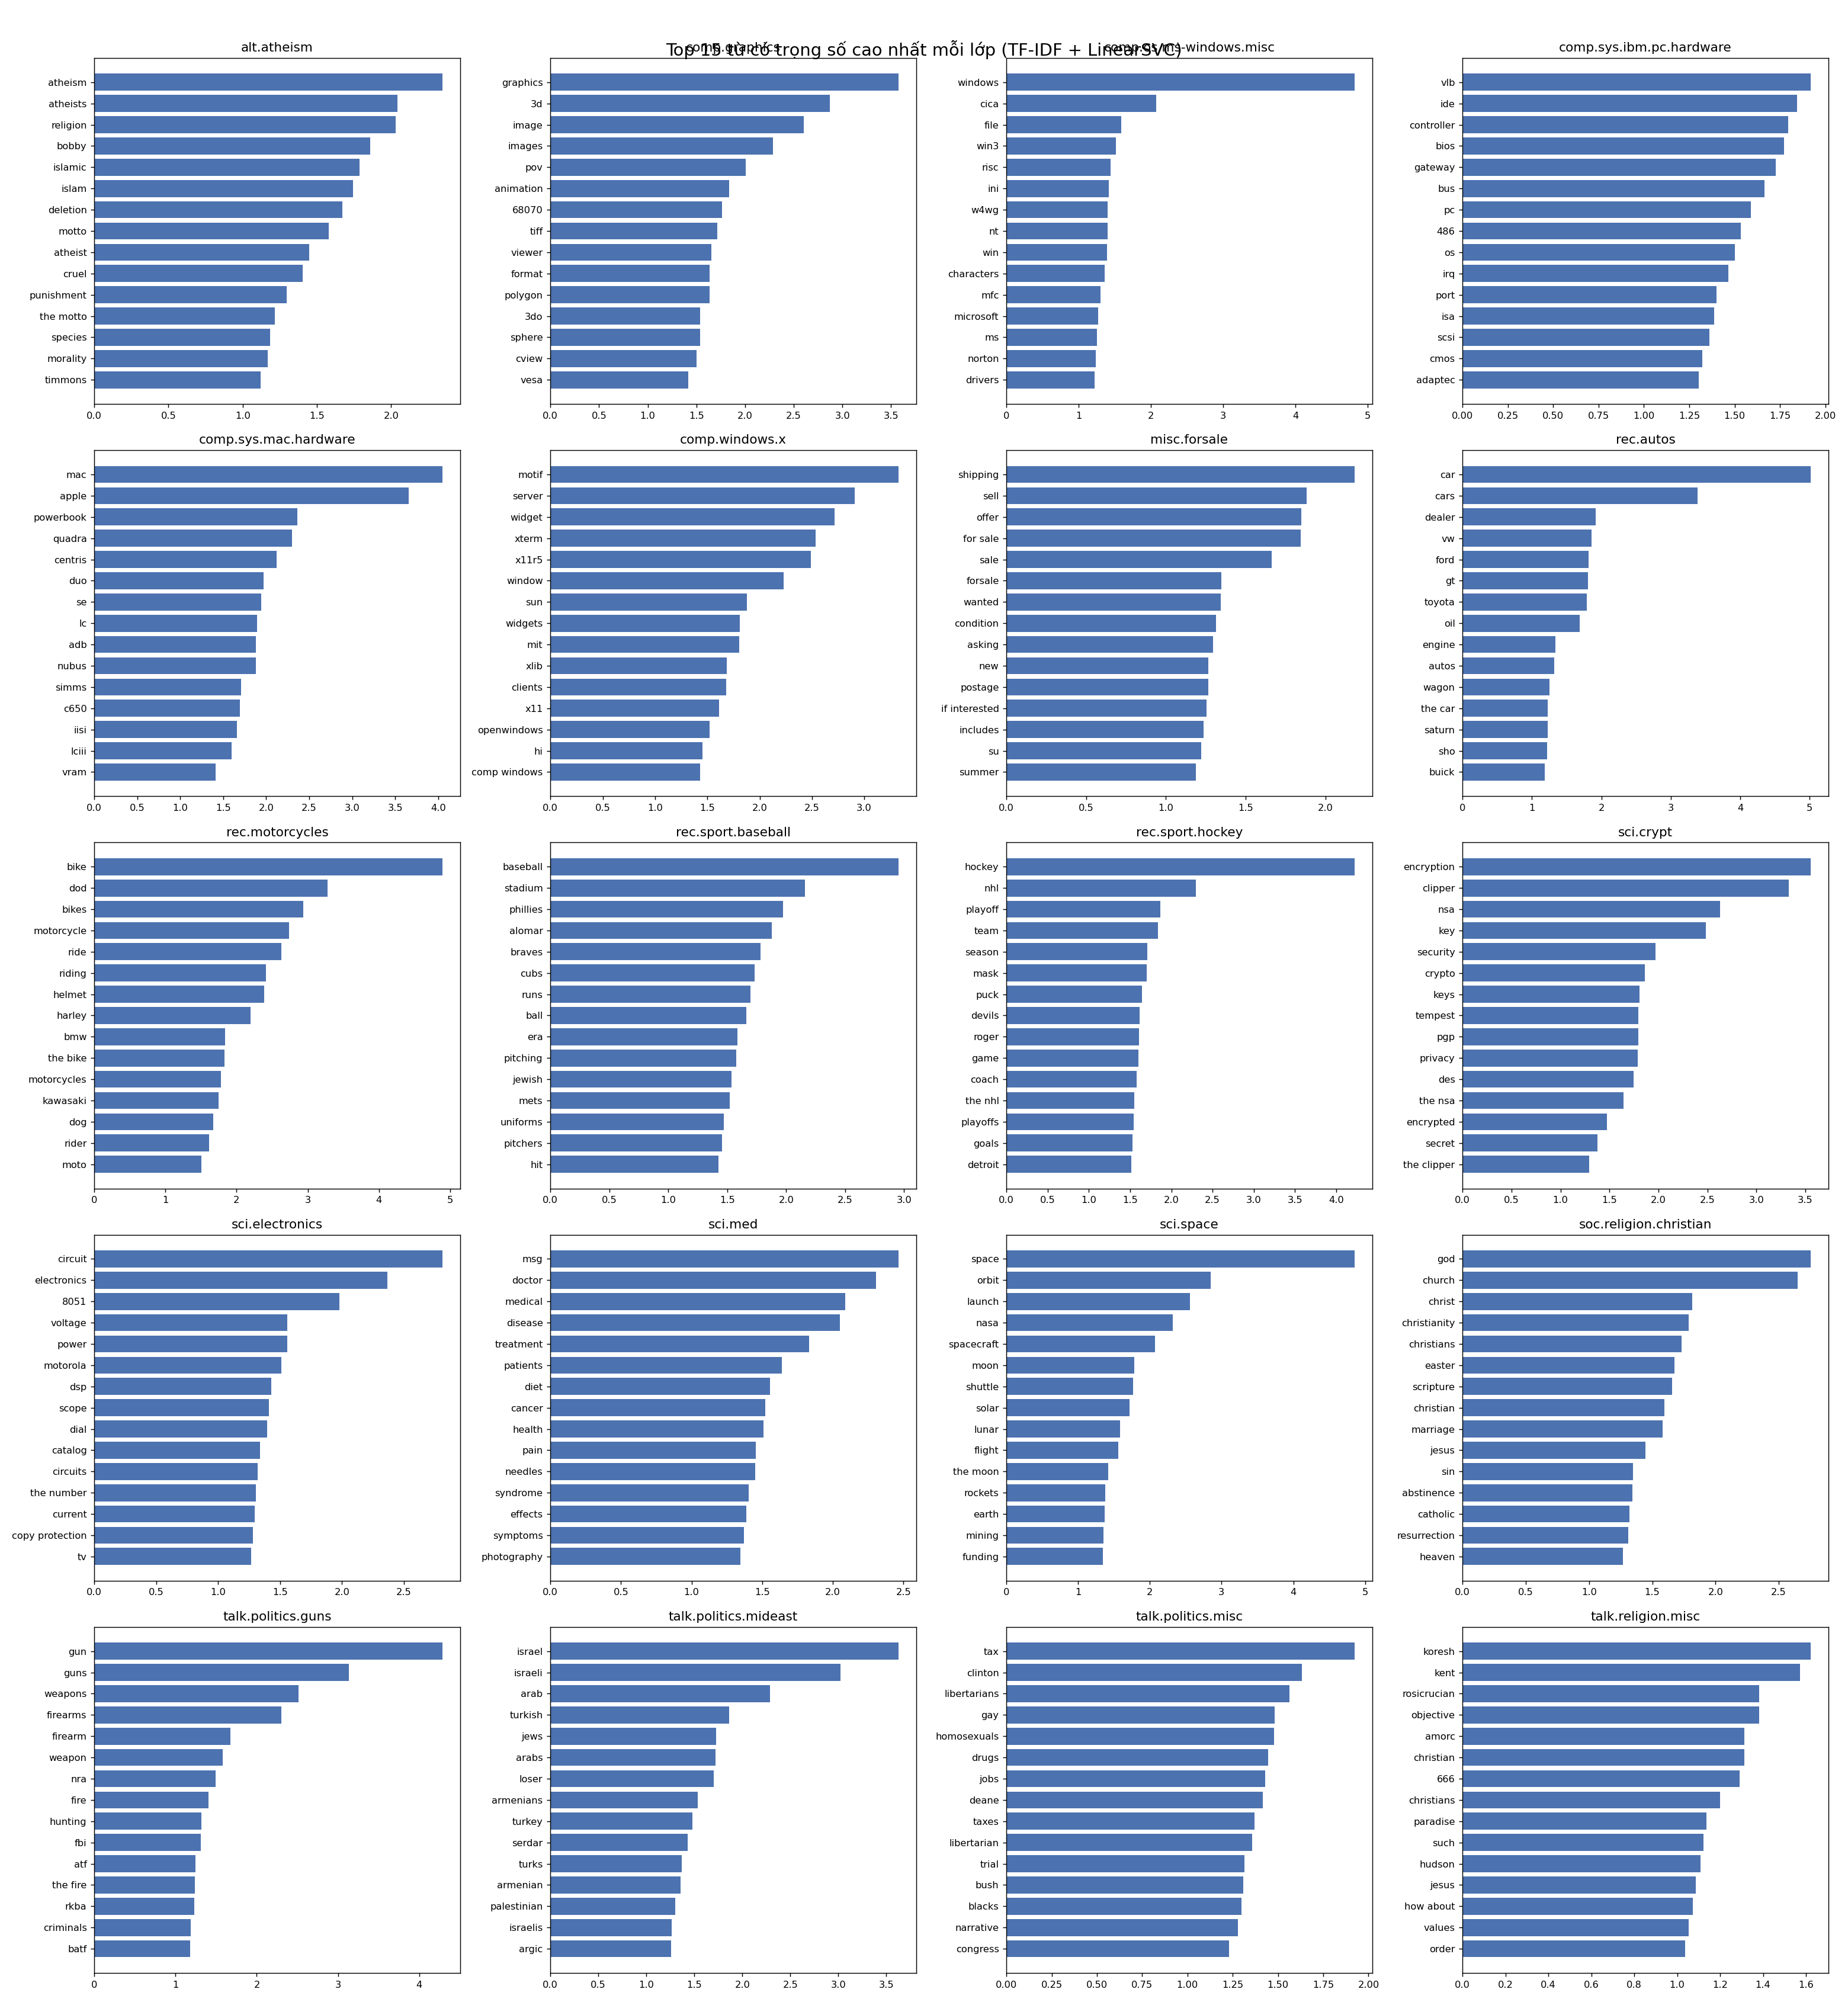

In [8]:
wide, flagged = T.b7_top_tu(fin)
print("⚠️ Nghi rò rỉ:", flagged if flagged else "không có token header/footer nào trong top 15")
display(wide)
hinh("top_tu_moi_lop.png")

## Bước 8 — Ma trận nhầm lẫn: nhóm chủ đề nào hay nhầm nhau?

,Thực tế,Bị nhầm thành,Số ca,Tỉ lệ nhầm
0,talk.politics.misc,talk.politics.guns,80,0.258065
1,talk.religion.misc,soc.religion.christian,52,0.207171
2,comp.windows.x,comp.graphics,51,0.129114
3,talk.religion.misc,alt.atheism,41,0.163347
4,alt.atheism,soc.religion.christian,39,0.122257
5,comp.os.ms-windows.misc,comp.sys.ibm.pc.hardware,37,0.093909
6,comp.sys.ibm.pc.hardware,comp.os.ms-windows.misc,36,0.091837
7,comp.sys.ibm.pc.hardware,sci.electronics,34,0.086735
8,comp.sys.ibm.pc.hardware,comp.sys.mac.hardware,32,0.081633
9,rec.motorcycles,rec.autos,27,0.067839


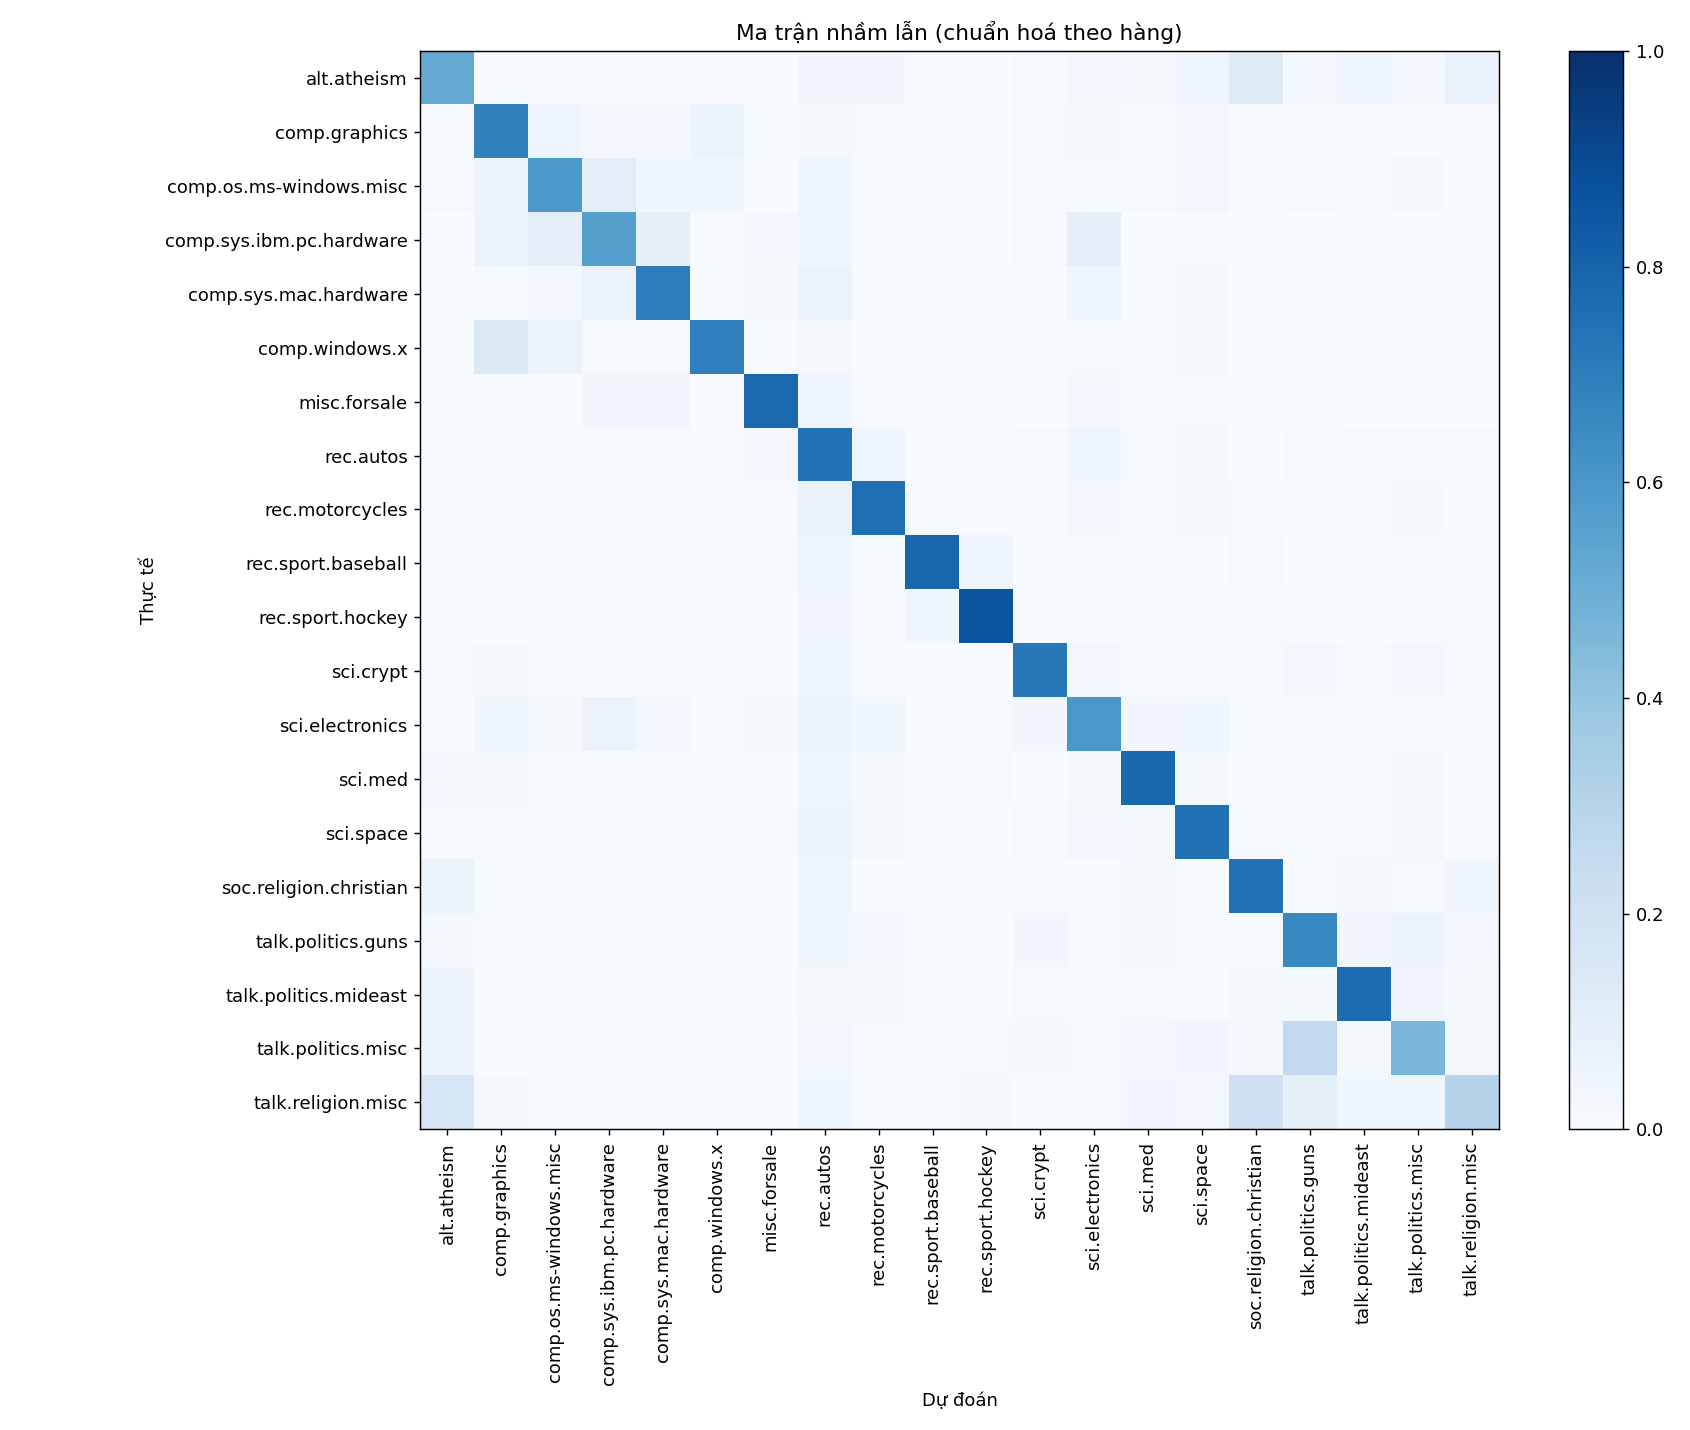

In [9]:
display(T.b8_confusion(fin)); hinh("confusion_matrix.png")

## Bước 9 — Cơ chế ngưỡng tin cậy
Nếu `max(proba) < 0,6` → chuyển người xử lý. Bảng: % tự động · accuracy phần tự động · % cần người.

,Ngưỡng,% tự động,Accuracy phần tự động,% cần người,Accuracy phần cần người (nếu để máy quyết)
0,0.3,87.772172,0.755710,12.227828,0.181325
1,0.4,79.845990,0.798304,20.154010,0.238472
2,0.5,69.158258,0.847572,30.841742,0.321997
3,0.6,57.355284,0.892361,42.644716,0.407223
4,0.7,45.300053,0.924091,54.699947,0.487864
5,0.8,28.000531,0.951636,71.999469,0.581966
6,0.9,5.775358,0.981609,94.224642,0.667324


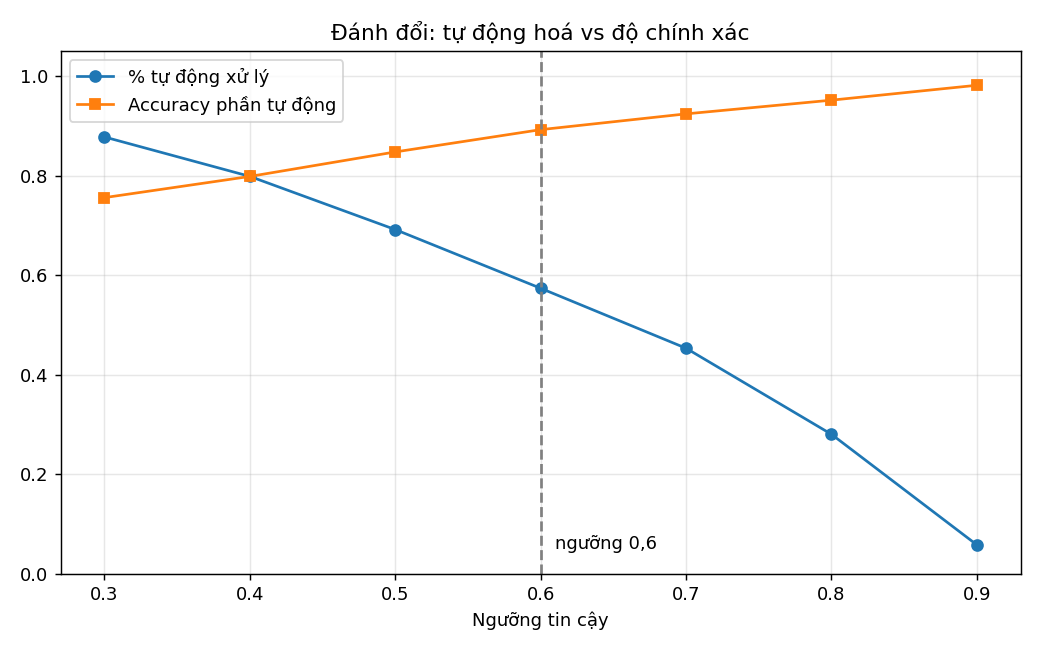

In [10]:
display(T.b9_nguong_tin_cay(fin)); hinh("nguong_tin_cay.png")

## Bước 10 — Đo thời gian (dự đoán 1 ticket phải < 5 ms)

In [11]:
T.b10_thoi_gian(fin)

,Chỉ số,Giá trị
0,Train toàn bộ pipeline (giây),21.53
1,"Dự đoán 1 ticket — trung bình (ms, 300 ticket)",3.333
2,Dự đoán 1 ticket — trung vị (ms),3.07
3,Dự đoán 1 ticket — p95 (ms),6.226
4,Đạt yêu cầu < 5 ms (trung bình),ĐẠT


## Bước 11 — Phân tích 10 ca sai
5 ca sai với độ tin cậy cao nhất + 5 ca ngẫu nhiên. Cột nguyên nhân là **gợi ý tự động**; hãy đọc trích đoạn để kết luận.

In [12]:
T.b11_ca_sai(fin)

,Thực tế,Dự đoán,Độ tin cậy,Nguyên nhân (gợi ý),Trích đoạn
0,comp.sys.ibm.pc.hardware,misc.forsale,0.941854,Văn bản quá ngắn/rỗng — thiếu từ khoá để phân biệt,"I have a Always IN-2000 SCSI card for sale w/manuals, software, and cables. Make your ..."
1,alt.atheism,sci.crypt,0.939018,"Chứa từ khoá đặc trưng của lớp dự đoán, hoặc nhãn gốc nhiễu / chủ đề lệch","The CLIPPER initiative is an announcement by Clinton that all the ""secure"" voice phone..."
2,talk.religion.misc,sci.space,0.934435,"Chứa từ khoá đặc trưng của lớp dự đoán, hoặc nhãn gốc nhiễu / chủ đề lệch",The following partial summary of a Theory of the Universe includes a little-known desc...
3,comp.graphics,comp.os.ms-windows.misc,0.905918,Hai lớp cùng nhóm 'máy tính' — từ vựng chồng lấn mạnh,"There are some tricks to installing ATM to windows... install them first to dos, then ..."
4,comp.os.ms-windows.misc,comp.graphics,0.905522,Hai lớp cùng nhóm 'máy tính' — từ vựng chồng lấn mạnh,I am working with 24 bit RGB BMP files and need to comvert these to 15 and 16 bit imag...
5,talk.religion.misc,soc.religion.christian,0.724550,Hai lớp cùng nhóm 'tôn giáo' — từ vựng chồng lấn mạnh,"In God, whose word I praise, in God I trust; I will not be afraid. What can mortal man..."
6,soc.religion.christian,talk.religion.misc,0.546020,Hai lớp cùng nhóm 'tôn giáo' — từ vựng chồng lấn mạnh,"[I'm going to cut ""Rex""'s ramblings down a bit.] [...] Rex, there are literally hundre..."
7,comp.sys.ibm.pc.hardware,sci.electronics,0.713511,"Chứa từ khoá đặc trưng của lớp dự đoán, hoặc nhãn gốc nhiễu / chủ đề lệch","is this the KX-P1124 you're talking about? or is there a KX-1124, too? I'll assume you..."
8,comp.sys.mac.hardware,rec.autos,0.093556,Văn bản quá ngắn/rỗng — thiếu từ khoá để phân biệt,
9,comp.windows.x,comp.graphics,0.864618,Hai lớp cùng nhóm 'máy tính' — từ vựng chồng lấn mạnh,"How do I view .eps files on X? I have an image in color encapsulated postscript, and n..."


## Hạn chế: TF-IDF không hiểu NGHĨA
Từ đồng nghĩa nhưng khác mặt chữ cho độ tương đồng ≈ 0.

In [13]:
T.han_che(fin)

,Câu A,Câu B,Cosine TF-IDF
0,the car is very fast,the automobile is really quick,0.013876
1,the car is very fast,the car is very fast indeed,0.944124
2,great graphics card,excellent video adapter,0.000000


## Demo định tuyến 1 ticket với ngưỡng tin cậy

In [14]:
from predict import route
route("My graphics card driver keeps crashing when I run 3D games", fin["pipe"], fin["names"])

{'bo_phan': 'comp.graphics',
 'do_tin_cay': 0.877,
 'quyet_dinh': 'TỰ ĐỘNG',
 'top3': [('comp.graphics', 0.877),
  ('rec.sport.baseball', 0.052),
  ('comp.os.ms-windows.misc', 0.019)]}

## Mở rộng (tuỳ chọn)
1. **SVD/LSA** giảm chiều — có tăng accuracy không? 2. **Học trực tuyến** với `SGDClassifier.partial_fit`.
Chạy cell dưới (hoặc `python src/train.py --extensions`).

In [15]:
lsa, online = T.mo_rong(fin)
display(lsa); display(online)

,Phương pháp,Accuracy,Thời gian fit (s)
0,TF-IDF + LinearSVC (50.000 chiều),0.685475,21.529671
1,LSA 300 chiều + LinearSVC,0.634227,35.126122


,Đã học (số lô),Số ticket đã thấy,Accuracy
0,1,2263,0.336166
1,2,4526,0.415693
2,3,6789,0.446229
3,4,9052,0.470526
4,5,11314,0.527217
